# Minimarket — Analytics Notebook

Connects directly to the **ClickHouse Data Warehouse** (marts built by dbt) and
answers the three required analytical questions:

1. **Top 5 products per category** (Apa 5 produk terlaris (berdasarkan total quantity terjual) untuk setiap kategori produk?)
2. **Monthly revenue trend** (Bagaimana trend total pendapatan (revenue) per bulan selama periode data yang tersedia?)
3. **Payment-method distribution** (Berapa persentase penggunaan setiap metode pembayaran (cash, debit, credit, e-wallet) dari total transaksi?)

> Run order: top to bottom. Make sure the pipeline has run (`minimarket_pipeline` DAG
> succeeded in Airflow) so `analytics.fact_sales`, `analytics.dim_product`, and
> `analytics.dim_date` exist.


In [ ]:
import os
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Defaults to localhost so the notebook also works when run on the host machine.
# Inside the jupyter container, CLICKHOUSE_HOST is set to 'clickhouse'.
client = clickhouse_connect.get_client(
    host=os.getenv("CLICKHOUSE_HOST", "localhost"),
    port=int(os.getenv("CLICKHOUSE_PORT", "8123")),
    username=os.getenv("CLICKHOUSE_USER", "default"),
    password=os.getenv("CLICKHOUSE_PASSWORD", ""),
)
DB = os.getenv("CLICKHOUSE_DB", "analytics")
print("Connected to ClickHouse. Marts database:", DB)


Connected to ClickHouse. Marts database: analytics


## Q1 — Produk Terlaris per Kategori

*"Apa 5 produk terlaris (berdasarkan total quantity terjual) untuk setiap kategori produk?"*


In [ ]:
q1 = f"""
SELECT
    p.category      AS category,
    p.product_name  AS product_name,
    sum(f.quantity) AS total_qty
FROM {DB}.fact_sales AS f
JOIN {DB}.dim_product AS p ON f.product_id = p.product_id
GROUP BY category, product_name
"""
df1 = client.query_df(q1)

# top 5 per category
top5 = (df1.sort_values(["category", "total_qty"], ascending=[True, False])
            .groupby("category")
            .head(5))
top5.head(10)


,category,product_name,total_qty
49,Beverages,Teh Botol Ratione,717
75,Beverages,Pocari Itaque 500ml,715
4,Beverages,Coca-Cola Ipsa Refill,680
70,Beverages,Coca-Cola Quas Refill,679
32,Beverages,Pocari Earum 250ml,623
48,Dairy,Greenfields Enim 500ml,739
47,Dairy,Frisian Flag Vitae,714
10,Dairy,Greenfields Harum Pack,708
64,Dairy,Cimory Numquam,691
58,Dairy,Frisian Flag Eligendi 250ml,655


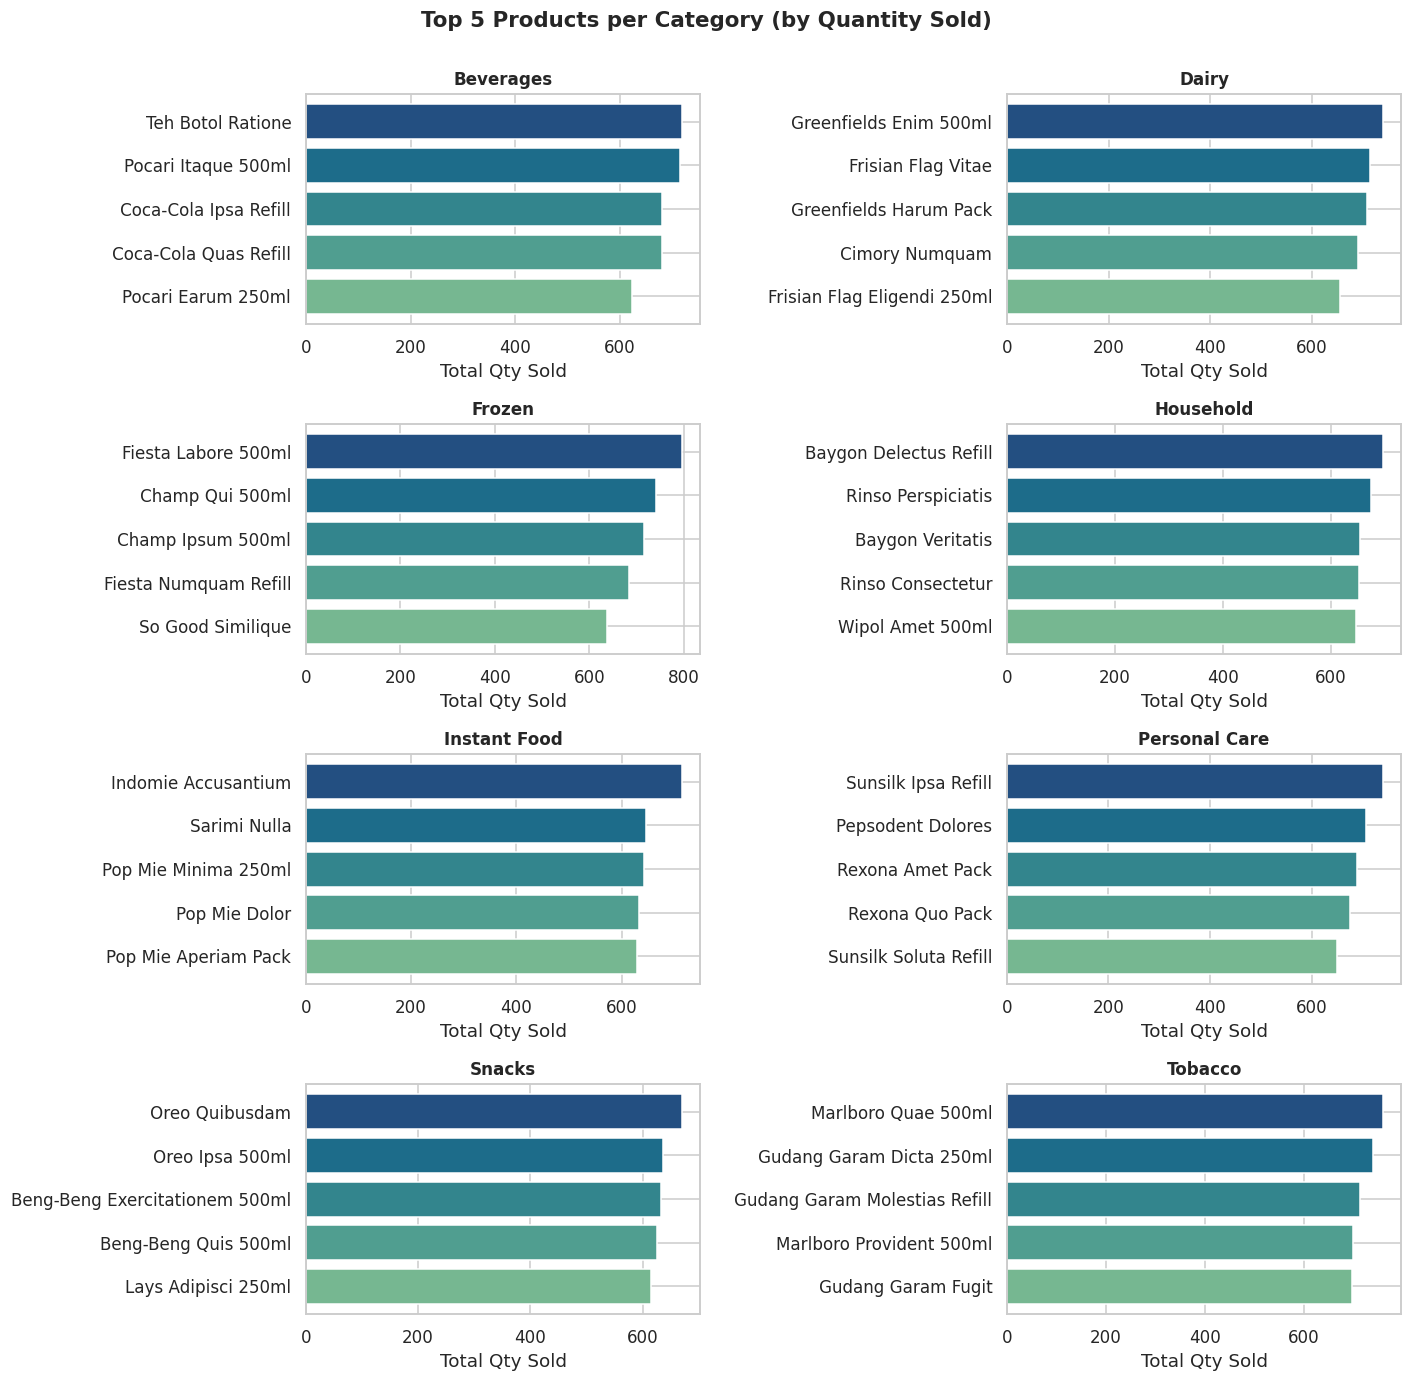

In [ ]:
categories = sorted(top5["category"].unique())
n = len(categories)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = axes.flatten()

for ax, cat in zip(axes, categories):
    sub = top5[top5["category"] == cat].sort_values("total_qty")
    ax.barh(sub["product_name"], sub["total_qty"], color=sns.color_palette("crest", len(sub)))
    ax.set_title(cat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Total Qty Sold")

# hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Top 5 Products per Category (by Quantity Sold)", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## Q2 — Trend Penjualan Bulanan

*"Bagaimana trend total pendapatan (revenue) per bulan selama periode data yang tersedia?"*


In [ ]:
q2 = f"""
SELECT
    d.year_month     AS year_month,
    sum(f.subtotal)  AS revenue
FROM {DB}.fact_sales AS f
JOIN {DB}.dim_date AS d ON f.transaction_day = d.date_day
GROUP BY year_month
ORDER BY year_month
"""
df2 = client.query_df(q2)
df2["revenue"] = df2["revenue"].astype(float)
df2


,year_month,revenue
0,2025-06,4221350.0
1,2025-07,20686375.0
2,2025-08,40906250.0
3,2025-09,59355675.0
4,2025-10,87944375.0
5,2025-11,106187450.0
6,2025-12,126826275.0
7,2026-01,155052875.0
8,2026-02,151988825.0
9,2026-03,166846900.0


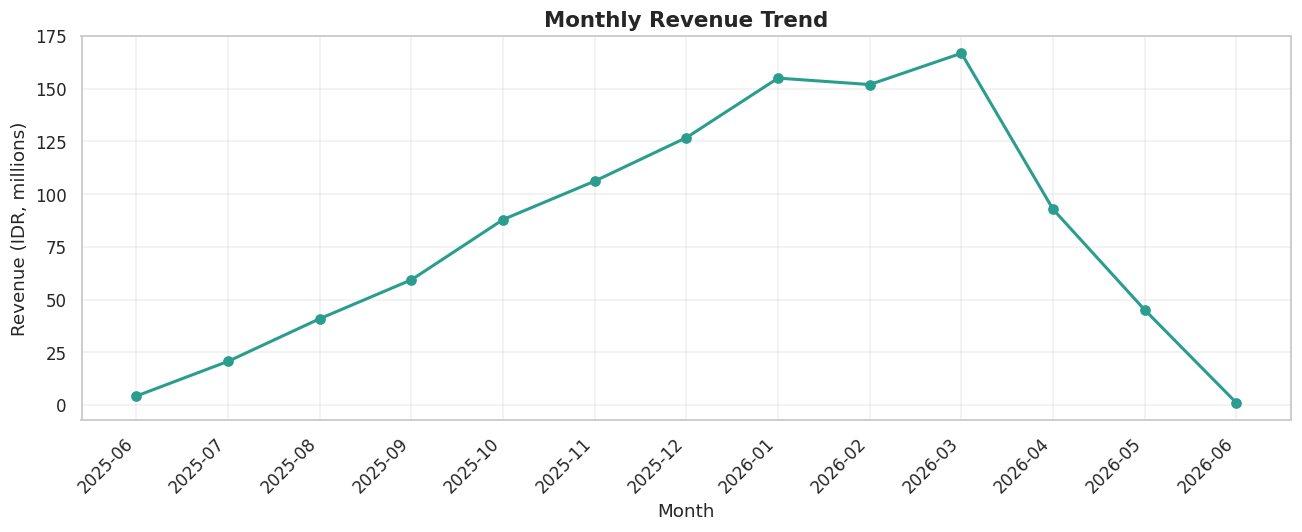

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df2["year_month"], df2["revenue"] / 1e6, marker="o", color="#2a9d8f", linewidth=2)
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (IDR, millions)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Q3 — Distribusi Metode Pembayaran

*"Berapa persentase penggunaan setiap metode pembayaran (cash, debit, credit, e-wallet) dari total transaksi?"*


In [ ]:
q3 = f"""
SELECT
    f.payment_method               AS payment_method,
    count(DISTINCT f.transaction_id) AS txn_count
FROM {DB}.fact_sales AS f
GROUP BY payment_method
ORDER BY txn_count DESC
"""
df3 = client.query_df(q3)
df3["pct"] = (df3["txn_count"] / df3["txn_count"].sum() * 100).round(1)
df3


,payment_method,txn_count,pct
0,cash,2068,38.4
1,e-wallet,1380,25.6
2,debit,1194,22.2
3,credit,744,13.8


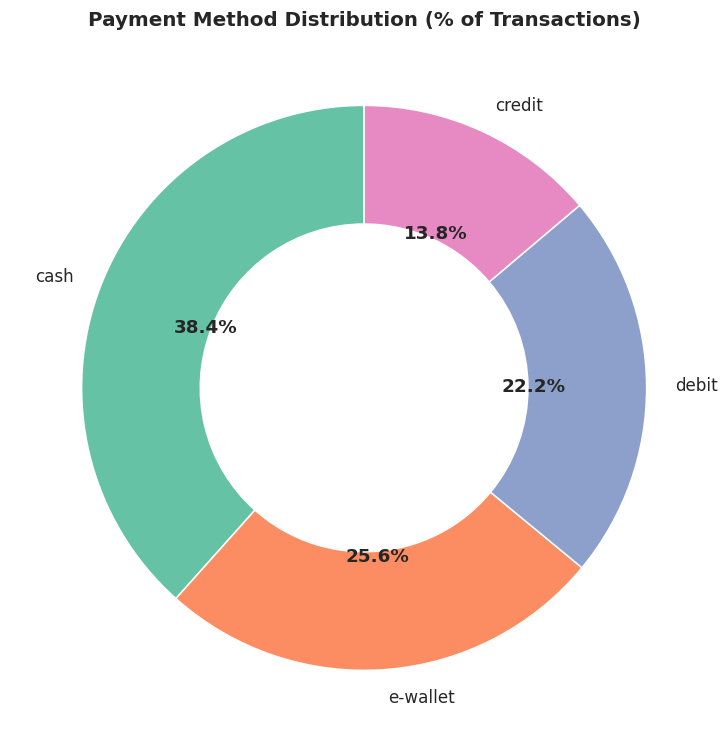

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", len(df3))
wedges, _texts, autotexts = ax.pie(
    df3["txn_count"],
    labels=df3["payment_method"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
ax.set_title("Payment Method Distribution (% of Transactions)", fontsize=13, fontweight="bold")
plt.setp(autotexts, weight="bold")
plt.tight_layout()
plt.show()
